<a href="https://colab.research.google.com/github/Sezikeye/Assignment-AI/blob/main/Assignment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
!unzip images.zip
data_dir = "images"
images = []
labels = []


Archive:  images.zip
   creating: images/
   creating: images/dalmatian/
  inflating: images/dalmatian/image_0001.jpg  
  inflating: images/dalmatian/image_0002.jpg  
  inflating: images/dalmatian/image_0003.jpg  
  inflating: images/dalmatian/image_0004.jpg  
  inflating: images/dalmatian/image_0005.jpg  
  inflating: images/dalmatian/image_0006.jpg  
  inflating: images/dalmatian/image_0007.jpg  
  inflating: images/dalmatian/image_0008.jpg  
  inflating: images/dalmatian/image_0009.jpg  
  inflating: images/dalmatian/image_0010.jpg  
  inflating: images/dalmatian/image_0011.jpg  
  inflating: images/dalmatian/image_0012.jpg  
  inflating: images/dalmatian/image_0013.jpg  
  inflating: images/dalmatian/image_0014.jpg  
  inflating: images/dalmatian/image_0015.jpg  
  inflating: images/dalmatian/image_0016.jpg  
  inflating: images/dalmatian/image_0017.jpg  
  inflating: images/dalmatian/image_0018.jpg  
  inflating: images/dalmatian/image_0019.jpg  
  inflating: images/dalmatian/imag

In [ ]:
for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
if os.path.isdir(class_path):
    for image_file in os.listdir(class_path):
        img_path = os.path.join(class_path, image_file)

        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            images.append(img)
            labels.append(label)
        except:
              continue



In [ ]:
# we convert to numpy
X = np.array(images)
y = np.array(labels)

print("Dataset Shape",X.shape)


Dataset Shape (85, 64, 64)


In [ ]:
# Flatten images
X = X.reshape(X.shape[0], -1)


In [ ]:
#scale data
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [ ]:
# Train test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
# Model  creation
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)


KNeighborsClassifier()

In [ ]:
# we evaluate  the  model
y_pred = knn.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

   sunflower       1.00      1.00      1.00        17

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17

[[17]]
[[17]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


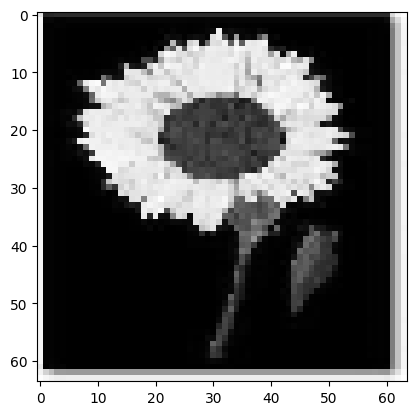

In [ ]:
sample_image = images[0]
plt.imshow(sample_image, cmap='gray')
plt.show()

In [ ]:
#Prepare image:
sample = sample_image.reshape(1, -1)
sample = scaler.transform(sample)

In [ ]:
#Predict:
prediction = knn.predict(sample)
print(prediction)


['sunflower']
